In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.datasets import mnist
from sklearn.datasets import fetch_olivetti_faces
import scipy.io
from PIL import Image
import random
from scipy import optimize
from sklearn.manifold import SpectralEmbedding
from sklearn.metrics.pairwise import euclidean_distances
import os
import random

# t-SNE

In [ ]:
# lets define our t-SNE function
def grid_search(diff_i: np.ndarray, i: int, perplexity: int) -> float:
    """
    Helper function to obtain σ's based on user-specified perplexity.

    Parameters:
        diff_i (np.ndarray): Array containing the pairwise differences between data points.
        i (int): Index of the current data point.
        perplexity (int): User-specified perplexity value.

    Returns:
        float: The value of σ that satisfies the perplexity condition.
    """

    result = np.inf  # Set first result to be infinity

    norm = np.linalg.norm(diff_i, axis=1)
    std_norm = np.std(norm)  # Use standard deviation of norms to define search space

    for sigma_search in np.linspace(0.01 * std_norm, 5 * std_norm, 200):
        # Equation 1 Numerator
        p = np.exp(-(norm**2) / (2 * sigma_search**2))

        # Set p = 0 when i = j
        p[i] = 0

        # Equation 1 (ε -> 0)
        epsilon = np.nextafter(0, 1)
        p_new = np.maximum(p / (np.sum(p)+epsilon), epsilon)

        # Shannon Entropy
        H = -np.sum(p_new * np.log2(p_new))

        # Get log(perplexity equation) as close to equality
        if np.abs(np.log(perplexity) - H * np.log(2)) < np.abs(result):
            result = np.log(perplexity) - H * np.log(2)
            sigma = sigma_search

    return sigma

def get_original_pairwise_affinities(X: np.ndarray, perplexity: int = 10) -> np.ndarray:
    """
    Function to obtain affinities matrix.

    Parameters:
    X (np.ndarray): The input data array.
    perplexity (int): The perplexity value for the grid search.

    Returns:
    np.ndarray: The pairwise affinities matrix.
    """

    n = len(X)

    print("Computing Pairwise Affinities....")

    p_ij = np.zeros(shape=(n, n))
    for i in range(0, n):
        # Equation 1 numerator
        diff = X[i] - X
        sigma_i = grid_search(diff, i, perplexity)  # Grid Search for σ_i
        norm = np.linalg.norm(diff, axis=1)
        p_ij[i, :] = np.exp(-(norm**2) / (2 * sigma_i**2))

        # Set p = 0 when j = i
        np.fill_diagonal(p_ij, 0)

        # Equation 1
        p_ij[i, :] = p_ij[i, :] / np.sum(p_ij[i, :])

    # Set 0 values to minimum numpy value (ε approx. = 0)
    epsilon = np.nextafter(0, 1)
    p_ij = np.maximum(p_ij, epsilon)

    print("Completed Pairwise Affinities Matrix. n")

    return p_ij


def get_symmetric_p_ij(p_ij: np.ndarray) -> np.ndarray:
    """
    Function to obtain symmetric affinities matrix utilized in t-SNE.

    Parameters:
    p_ij (np.ndarray): The input affinity matrix.

    Returns:
    np.ndarray: The symmetric affinities matrix.

    """
    print("Computing Symmetric p_ij matrix....")

    n = len(p_ij)
    p_ij_symmetric = np.zeros(shape=(n, n))
    for i in range(0, n):
        for j in range(0, n):
            p_ij_symmetric[i, j] = (p_ij[i, j] + p_ij[j, i]) / (2 * n)

    # Set 0 values to minimum numpy value (ε approx. = 0)
    epsilon = np.nextafter(0, 1)
    p_ij_symmetric = np.maximum(p_ij_symmetric, epsilon)

    print("Completed Symmetric p_ij Matrix. n")

    return p_ij_symmetric

def initialization(
    X: np.ndarray, n_dimensions: int = 2, initialization: str = "PCA"
) -> np.ndarray:
    """
    Obtain initial solution for t-SNE either randomly or using PCA.

    Parameters:
        X (np.ndarray): The input data array.
        n_dimensions (int): The number of dimensions for the output solution. Default is 2.
        initialization (str): The initialization method. Can be 'random' or 'PCA'. Default is 'PCA'.

    Returns:
        np.ndarray: The initial solution for t-SNE.

    Raises:
        ValueError: If the initialization method is neither 'random' nor 'PCA'.
    """

    # Sample Initial Solution
    if initialization == "random" or initialization != "PCA":
        y0 = np.random.normal(loc=0, scale=1e-4, size=(len(X), n_dimensions))
    elif initialization == "PCA":
        X_centered = X - X.mean(axis=0)
        _, _, Vt = np.linalg.svd(X_centered)
        y0 = X_centered @ Vt.T[:, :n_dimensions]
    else:
        raise ValueError("Initialization must be 'random' or 'PCA'")

    return y0


def get_low_dimensional_affinities_d(Y: np.ndarray) -> np.ndarray:
    """
    Obtain low-dimensional affinities.

    Parameters:
    Y (np.ndarray): The low-dimensional representation of the data points.

    Returns:
    np.ndarray: The low-dimensional affinities matrix.
    """

    n = len(Y)
    q_ij = np.zeros(shape=(n, n))

    for i in range(0, n):
        # Equation 4 Numerator
        diff = Y[i] - Y
        norm = np.linalg.norm(diff, axis=1)
        q_ij[i, :] = (1 + norm**2) ** (-1 / 1)

    # Set p = 0 when j = i
    np.fill_diagonal(q_ij, 0)

    # Equation 4
    q_ij = q_ij / q_ij.sum()

    # Set 0 values to minimum numpy value (ε approx. = 0)
    ε = np.nextafter(0, 1)
    q_ij = np.maximum(q_ij, ε)

    return q_ij

def get_gradient_d(p_ij: np.ndarray, q_ij: np.ndarray, Y: np.ndarray) -> np.ndarray:
    """
    Obtain gradient of cost function at current point Y.

    Parameters:
    p_ij (np.ndarray): The joint probability distribution matrix.
    q_ij (np.ndarray): The Student's t-distribution matrix.
    Y (np.ndarray): The current point in the low-dimensional space.

    Returns:
    np.ndarray: The gradient of the cost function at the current point Y.
    """

    n = len(p_ij)

    # Compute gradient
    gradient = np.zeros(shape=(n, Y.shape[1]))
    for i in range(0, n):
        # Equation 5
        diff = Y[i] - Y
        A = np.array([(p_ij[i, :] - q_ij[i, :])])
        #B = np.array([(1 + (np.linalg.norm(diff, axis=1)) ** 2) ** (-1)])
        B = np.array(1.0 / (1 * (1.0 + np.linalg.norm(diff, axis = 1) ** 2 )))
        C = diff
        gradient[i] = 4 * np.sum((A * B).T * C, axis=0)

    return gradient

def tsne(
    X: np.ndarray,
    perplexity: int = 30,
    T: int = 1000,
    eta: int = 100,
    early_exaggeration: int = 1,
    n_dimensions: int = 2,
) -> np.ndarray:
    """
    t-SNE (t-Distributed Stochastic Neighbor Embedding) algorithm implementation.

    Args:
        X (np.ndarray): The input data matrix of shape (n_samples, n_features).
        perplexity (int, optional): The perplexity parameter. Default is 10.
        T (int, optional): The number of iterations for optimization. Default is 1000.
        η (int, optional): The learning rate for updating the low-dimensional embeddings. Default is 200.
        early_exaggeration (int, optional): The factor by which the pairwise affinities are exaggerated
            during the early iterations of optimization. Default is 4.
        n_dimensions (int, optional): The number of dimensions of the low-dimensional embeddings. Default is 2.

    Returns:
        list[np.ndarray, np.ndarray]: A list containing the final low-dimensional embeddings and the history
            of embeddings at each iteration.

    """
    n = len(X)

    # Get original affinities matrix
    p_ij = get_original_pairwise_affinities(X, perplexity)
    p_ij_symmetric = get_symmetric_p_ij(p_ij)

    # Initialization
    Y = np.zeros(shape=(T, n, n_dimensions))
    Y_minus1 = np.zeros(shape=(n, n_dimensions))
    Y[0] = Y_minus1
    Y1 = initialization(X, n_dimensions)
    Y[1] = np.array(Y1)

    print("Optimizing Low Dimensional Embedding....")
    # Optimization
    for t in range(1, T - 1):
        # Momentum &amp; Early Exaggeration
        if t < 250:
            alpha = 0
            early_exaggeration = early_exaggeration
        else:
            alpha = 0
            early_exaggeration = 1

        # Get Low Dimensional Affinities
        q_ij = get_low_dimensional_affinities_d(Y[t])

        # Get Gradient of Cost Function
        gradient = get_gradient_d(early_exaggeration * p_ij_symmetric, q_ij, Y[t])

        # Update Rule
        Y[t + 1] = Y[t] - eta * gradient + alpha * (Y[t] - Y[t - 1])  # Use negative gradient

        # Compute current value of cost function
        if t % 50 == 0 or t == 1:
            cost = np.sum(p_ij_symmetric * np.log(p_ij_symmetric / q_ij))
            print(f"Iteration {t}: Value of Cost Function is {cost}")

    print(
        f"Completed Low Dimensional Embedding: Final Value of Cost Function is {np.sum(p_ij_symmetric * np.log(p_ij_symmetric / q_ij))}"
    )
    solution = Y[-1]

    return solution

In [3]:
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Select only the first 500 images
x_train_t = x_train[:500]
y_train_t = y_train[:500]

# Flatten images from 28x28 to 784
x_train_t_flat = x_train_t.reshape((x_train_t.shape[0], -1)).astype(np.float32)
x_test_t_flat = x_test.reshape((x_test.shape[0], -1)).astype(np.float32)

# Normalize the data
scaler = StandardScaler()
x_train_t_scaled = scaler.fit_transform(x_train_t_flat)
x_test_t_scaled = scaler.transform(x_test_t_flat)

# Apply PCA with 40 components
pca = PCA(n_components=40)
x_train_t_pca = pca.fit_transform(x_train_t_scaled)
x_test_t_pca = pca.transform(x_test_t_scaled)

Computing Pairwise Affinities....
Completed Pairwise Affinities Matrix. n
Computing Symmetric p_ij matrix....
Completed Symmetric p_ij Matrix. n
Optimizing Low Dimensional Embedding....
Iteration 1: Value of Cost Function is 1.84636905058353
Iteration 50: Value of Cost Function is 1.0266767789643112
Iteration 100: Value of Cost Function is 0.8780656121830285
Iteration 150: Value of Cost Function is 0.8101934035281758
Iteration 200: Value of Cost Function is 0.7700632543179294
Iteration 250: Value of Cost Function is 0.7485321737624749
Iteration 300: Value of Cost Function is 0.7314410836390828
Iteration 350: Value of Cost Function is 0.7175299485716364
Iteration 400: Value of Cost Function is 0.7067379883251443
Iteration 450: Value of Cost Function is 0.6980697506613207
Iteration 500: Value of Cost Function is 0.6911177781839076
Iteration 550: Value of Cost Function is 0.6849381949317744
Iteration 600: Value of Cost Function is 0.6782150171442846
Iteration 650: Value of Cost Function i

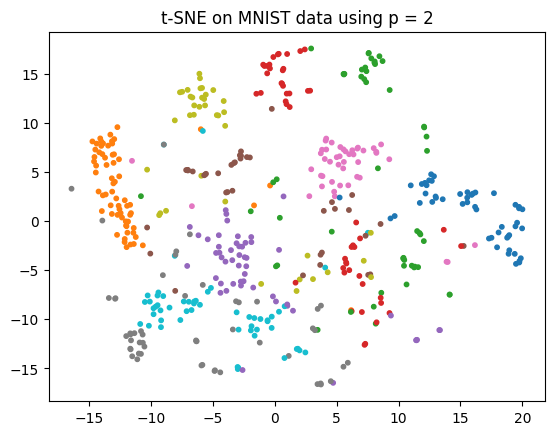

In [4]:
# Example usage of Daniel new beta function
Y = tsne(x_train_t_pca)

plt.scatter(Y[:, 0], Y[:, 1], c=y_train_t, cmap='tab10', s=10)
plt.title('t-SNE on MNIST data using p = 2')
plt.show()